<a href="https://colab.research.google.com/github/dai-fujiden/Kaggle/blob/main/noteboook/titanic/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

fujiden_titanic_path = kagglehub.dataset_download('fujiden/titanic')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fujiden/titanic/train.csv
/kaggle/input/datasets/fujiden/titanic/test.csv
/kaggle/input/datasets/fujiden/titanic/gender_submission.csv


In [ ]:
os.listdir("../input/datasets/fujiden/titanic")

['train.csv', 'test.csv', 'gender_submission.csv']

In [ ]:
df_train = pd.read_csv("../input/datasets/fujiden/titanic/train.csv")
df_test = pd.read_csv("../input/datasets/fujiden/titanic/test.csv")
df_sub = pd.read_csv("../input/datasets/fujiden/titanic/gender_submission.csv")

In [ ]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


nan値を除外

In [ ]:
df_train = df_train.dropna()

In [ ]:
for col in df_train.columns:
    if col in ["PassengerId", "Name", "Age", "Ticket", "Fare"]:
        continue

    print(f"{col}: {np.unique(df_train[col].dropna())}")

Survived: [0 1]
Pclass: [1 2 3]
Sex: ['female' 'male']
SibSp: [0 1 2 3]
Parch: [0 1 2 4]
Cabin: ['A10' 'A16' 'A20' 'A23' 'A24' 'A26' 'A31' 'A34' 'A36' 'A5' 'A6' 'A7'
 'B101' 'B18' 'B19' 'B20' 'B22' 'B3' 'B30' 'B35' 'B37' 'B38' 'B39' 'B4'
 'B41' 'B42' 'B49' 'B5' 'B50' 'B51 B53 B55' 'B57 B59 B63 B66' 'B58 B60'
 'B69' 'B71' 'B73' 'B77' 'B79' 'B80' 'B82 B84' 'B86' 'B94' 'B96 B98'
 'C101' 'C103' 'C104' 'C110' 'C111' 'C118' 'C123' 'C124' 'C125' 'C126'
 'C148' 'C2' 'C22 C26' 'C23 C25 C27' 'C30' 'C32' 'C45' 'C46' 'C49' 'C50'
 'C52' 'C54' 'C62 C64' 'C65' 'C68' 'C7' 'C70' 'C78' 'C82' 'C83' 'C85'
 'C86' 'C87' 'C90' 'C91' 'C92' 'C93' 'C99' 'D' 'D10 D12' 'D11' 'D15' 'D17'
 'D19' 'D20' 'D26' 'D28' 'D30' 'D33' 'D35' 'D36' 'D37' 'D46' 'D47' 'D48'
 'D49' 'D50' 'D56' 'D6' 'D7' 'D9' 'E10' 'E101' 'E12' 'E121' 'E17' 'E24'
 'E25' 'E31' 'E33' 'E34' 'E36' 'E38' 'E40' 'E44' 'E46' 'E49' 'E50' 'E58'
 'E63' 'E67' 'E68' 'E77' 'E8' 'F G63' 'F G73' 'F2' 'F33' 'F4' 'G6' 'T']
Embarked: ['C' 'Q' 'S']


为了完成机械学习问题选择有用的数据

In [ ]:

def one_hot_encoding(df):
    # Cabin の先頭文字を取り出す
    df["Deck"] = df["Cabin"].str[0]
    # One-Hot Encoding
    deck_dummies = pd.get_dummies(
        df["Deck"],
        prefix="Deck",
        dtype=bool
    )

    df["Sex"] = pd.get_dummies(df["Sex"],
                   drop_first=True,
                    dtype=int)

    df = pd.get_dummies(
        df,
        columns=["Embarked"],
        dtype=int
    )



    # 元のデータフレームに追加
    df = pd.concat(
        [df, deck_dummies],
        axis=1
    )
    return df
df_train = one_hot_encoding(df_train)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,...,0,0,False,False,True,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,...,0,1,False,False,True,False,False,False,False,False
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,...,0,1,False,False,False,False,True,False,False,False
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",0,4.0,1,1,PP 9549,16.7000,...,0,1,False,False,False,False,False,False,True,False
11,12,1,1,"Bonnell, Miss. Elizabeth",0,58.0,0,0,113783,26.5500,...,0,1,False,False,True,False,False,False,False,False


In [ ]:
print(df_train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Deck', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E',
       'Deck_F', 'Deck_G', 'Deck_T'],
      dtype='object')


            Survived       Sex      Fare     SibSp       Age    Pclass  \
Survived    1.000000 -0.532418  0.134241  0.106346 -0.254085 -0.034542   
Sex        -0.532418  1.000000 -0.130433 -0.104291  0.184969 -0.046181   
Fare        0.134241 -0.130433  1.000000  0.286433 -0.092424 -0.315235   
SibSp       0.106346 -0.104291  0.286433  1.000000 -0.156162 -0.103592   
Age        -0.254085  0.184969 -0.092424 -0.156162  1.000000 -0.306514   
Pclass     -0.034542 -0.046181 -0.315235 -0.103592 -0.306514  1.000000   
Embarked_C  0.104870 -0.062691  0.240382 -0.056723  0.085018 -0.231837   
Embarked_Q -0.038544 -0.004024  0.015625  0.169446  0.019038 -0.039131   
Embarked_S -0.095861  0.063146 -0.242172  0.019780 -0.088568  0.238755   
Deck_A     -0.050109  0.210777 -0.138541 -0.122810  0.155518 -0.098613   
Deck_B      0.085066 -0.085704  0.278442 -0.079704 -0.050394 -0.206306   
Deck_C     -0.111087 -0.011597  0.220260  0.233580  0.016425 -0.231388   
Deck_D      0.067153 -0.061023 -0.1209

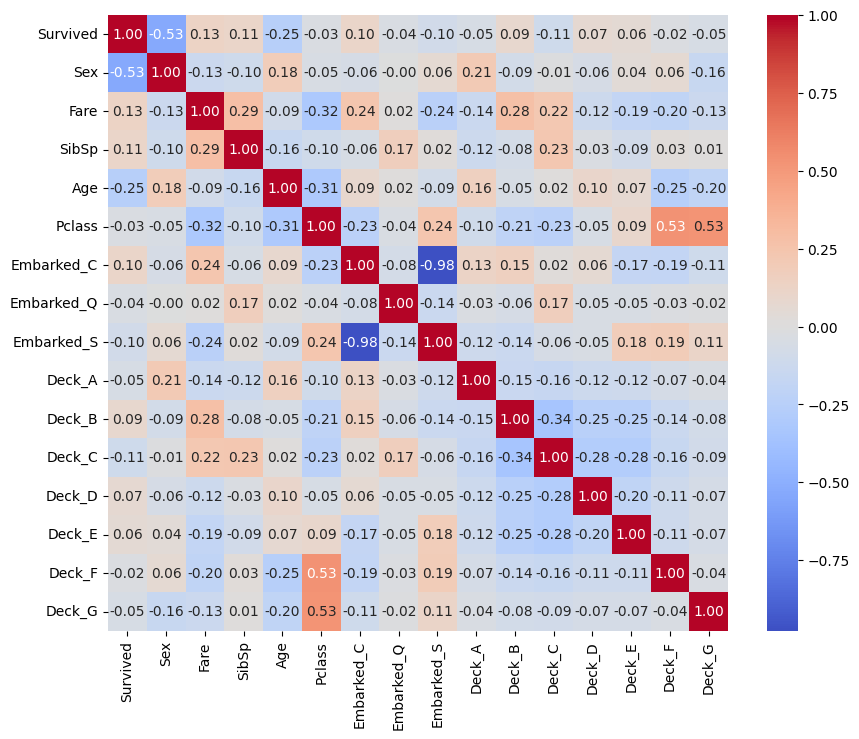

In [ ]:
binary_cols = [
    "Survived",
    "Sex",
    "Fare",
    "SibSp",
    "Age",
    "Pclass",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S",
    "Deck_A",
    "Deck_B",
    "Deck_C",
    "Deck_D",
    "Deck_E",
    "Deck_F",
    "Deck_G"
]

corr = df_train[binary_cols].corr()

print(corr)

import matplotlib.pyplot as plt
import seaborn as sns

corr = df_train[binary_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.show()

In [ ]:
column = corr.columns[1:]
X_train = df_train[column]
y_train = df_train["Survived"]
print("----"*5, "Train","----"*5)
print(X_train.head(4), f"\n",f"\n",)
print("----"*5, "Test","----"*5)
print(y_train.head(4))

-------------------- Train --------------------
    Sex     Fare  SibSp   Age  Pclass  Embarked_C  Embarked_Q  Embarked_S  \
1     0  71.2833      1  38.0       1           1           0           0   
3     0  53.1000      1  35.0       1           0           0           1   
6     1  51.8625      0  54.0       1           0           0           1   
10    0  16.7000      1   4.0       3           0           0           1   

    Deck_A  Deck_B  Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  
1    False   False    True   False   False   False   False  
3    False   False    True   False   False   False   False  
6    False   False   False   False    True   False   False  
10   False   False   False   False   False   False    True   
 

-------------------- Test --------------------
1     1
3     1
6     0
10    1
Name: Survived, dtype: int64


In [ ]:
df_test = df_test.dropna()

df_test = one_hot_encoding(df_test)
X_test = df_test[column]

In [ ]:
X_test

,Sex,Fare,SibSp,Age,Pclass,Embarked_C,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G
12,0,82.2667,1,23.0,1,0,0,1,False,True,False,False,False,False,False
14,0,61.1750,1,47.0,1,0,0,1,False,False,False,False,True,False,False
24,0,262.3750,1,48.0,1,1,0,0,False,True,False,False,False,False,False
26,0,61.9792,0,22.0,1,1,0,0,False,True,False,False,False,False,False
28,1,30.5000,0,41.0,1,0,0,1,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,1,27.7208,1,43.0,1,1,0,0,False,False,False,True,False,False,False
405,1,13.8625,0,20.0,2,1,0,0,False,False,False,True,False,False,False
407,1,211.5000,1,50.0,1,1,0,0,False,False,True,False,False,False,False
411,0,90.0000,1,37.0,1,0,1,0,False,False,True,False,False,False,False


## ランダムforestによる解法

In [ ]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import xgboost as xgb

clf_xg = xgb.XGBClassifier()
clf_xg.fit(X_train, y_train)

shap.initjs()
explainer_xg = shap.TreeExplainer(clf_xg)
shap_values_xg = np.array(explainer_xg.shap_values(X_train))
shap.force_plot(explainer_xg.expected_value, shap_values_xg[0,:],X_train.iloc[0,:])


In [ ]:
clf = RandomForestClassifier(random_state=199)
clf.fit(X_train, y_train)
df_test["Survived"] = clf.predict(X_test)

In [ ]:
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Survived
12,904,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",0,23.0,1,0,21228,82.2667,B45,...,0,1,False,True,False,False,False,False,False,1
14,906,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",0,47.0,1,0,W.E.P. 5734,61.1750,E31,...,0,1,False,False,False,False,True,False,False,1
24,916,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",0,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,...,0,0,False,True,False,False,False,False,False,1
26,918,1,"Ostby, Miss. Helene Ragnhild",0,22.0,0,1,113509,61.9792,B36,...,0,0,False,True,False,False,False,False,False,1
28,920,1,"Brady, Mr. John Bertram",1,41.0,0,0,113054,30.5000,A21,...,0,1,True,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,1296,1,"Frauenthal, Mr. Isaac Gerald",1,43.0,1,0,17765,27.7208,D40,...,0,0,False,False,False,True,False,False,False,1
405,1297,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",1,20.0,0,0,SC/PARIS 2166,13.8625,D38,...,0,0,False,False,False,True,False,False,False,1
407,1299,1,"Widener, Mr. George Dunton",1,50.0,1,1,113503,211.5000,C80,...,0,0,False,False,True,False,False,False,False,0
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",0,37.0,1,0,19928,90.0000,C78,...,1,0,False,False,True,False,False,False,False,1


            Survived       Sex      Fare     SibSp       Age    Pclass  \
Survived    1.000000 -0.624349  0.112434  0.257555 -0.074051 -0.040919   
Sex        -0.624349  1.000000 -0.179047 -0.170596 -0.022983  0.056699   
Fare        0.112434 -0.179047  1.000000  0.213014  0.180567 -0.298186   
SibSp       0.257555 -0.170596  0.213014  1.000000  0.062530 -0.132790   
Age        -0.074051 -0.022983  0.180567  0.062530  1.000000 -0.410924   
Pclass     -0.040919  0.056699 -0.298186 -0.132790 -0.410924  1.000000   
Embarked_C  0.049822  0.081655  0.225793 -0.185366  0.029547 -0.185316   
Embarked_Q  0.066556 -0.106600 -0.009974  0.068474 -0.016014 -0.034315   
Embarked_S -0.064194 -0.058981 -0.224137  0.171086 -0.026178  0.193067   
Deck_A     -0.195615  0.045661 -0.180152 -0.145669  0.073367 -0.094132   
Deck_B     -0.002189  0.005871  0.276461  0.055599  0.034790 -0.162534   
Deck_C     -0.122975 -0.060895  0.214527  0.187972  0.134545 -0.261074   
Deck_D      0.157432  0.038961 -0.2254

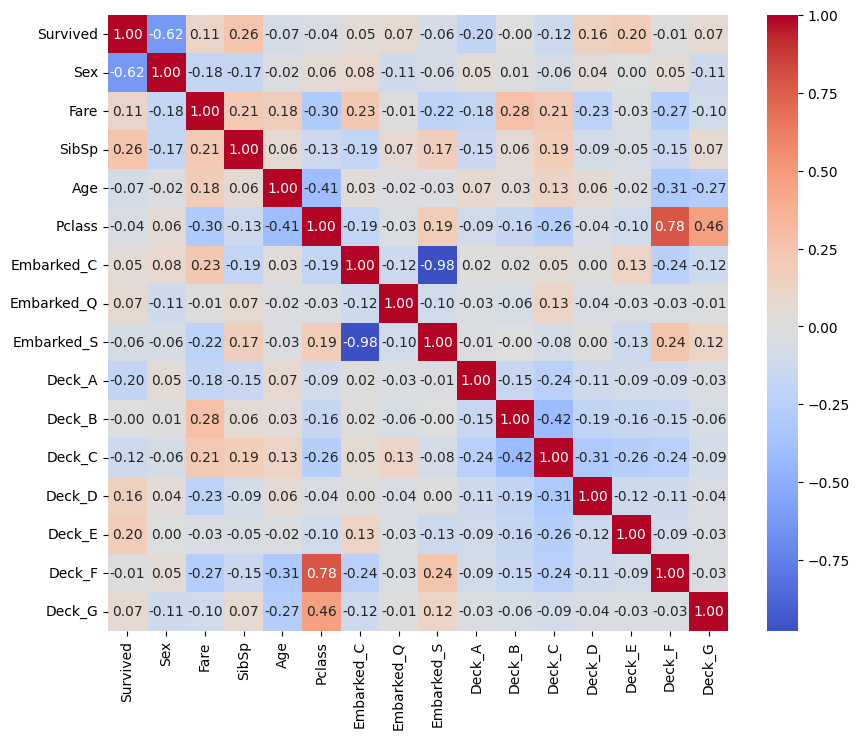

In [ ]:
binary_cols = [
    "Survived",
    "Sex",
    "Fare",
    "SibSp",
    "Age",
    "Pclass",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S",
    "Deck_A",
    "Deck_B",
    "Deck_C",
    "Deck_D",
    "Deck_E",
    "Deck_F",
    "Deck_G"
]

corr = df_test[binary_cols].corr()

print(corr)

import matplotlib.pyplot as plt
import seaborn as sns

corr = df_test[binary_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.show()

In [ ]:
df_sub

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
i = df_test["Survived"].index

_df_sub = df_sub.iloc[i]
_df_sub["answer"] = df_test["Survived"]

/tmp/ipykernel_58/930354157.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_sub["answer"] = df_test["Survived"]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    _df_sub["Survived"],
    _df_sub["answer"]
)

print(f"Accuracy = {accuracy:.4f}")

Accuracy = 0.7816


In [ ]:

def evaluate(df, column = "Survived", print_log = True):
    TP = 0
    TN = 0
    FP = 0
    FN = 0

    for _, row in df.iterrows():

        y_true = row["Survived"]
        y_pred = row[column]

        if y_true == 1 and y_pred == 1:
            TP += 1

        elif y_true == 0 and y_pred == 0:
            TN += 1

        elif y_true == 0 and y_pred == 1:
            FP += 1

        elif y_true == 1 and y_pred == 0:
            FN += 1

    correct = 0

    for i in range(len(df)):
        if df.iloc[i]["Survived"] == df.iloc[i][column]:
            correct += 1

    accuracy = correct / len(df)

    if print_log:
        print("TP =", TP)
        print("TN =", TN)
        print("FP =", FP)
        print("FN =", FN)
        print("Accuracy =", accuracy)
    return accuracy

In [ ]:
evaluate(df_train, column = "Survived")

TP = 123
TN = 60
FP = 0
FN = 0
Accuracy = 1.0


1.0

In [ ]:
evaluate(_df_sub, column = "answer")

TP = 44
TN = 24
FP = 19
FN = 0
Accuracy = 0.7816091954022989


0.7816091954022989

## NN による解法

In [ ]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp

# 標準化
X_train = (X_train - X_train.mean(axis=0)) / (X_train.std(axis=0) + 1e-8)
X_test_nn = jnp.array((X_test - X_test.mean(axis=0)) / (X_test.std(axis=0) + 1e-8))

In [ ]:
from flax import linen as nn

class TitanicNN(nn.Module):

    @nn.compact
    def __call__(self, x):

        x = nn.Dense(32)(x)
        x = nn.tanh(x)

        x = nn.Dense(32)(x)
        x = nn.tanh(x)

        x = nn.Dense(32)(x)
        x = nn.tanh(x)

        x = nn.Dense(32)(x)
        x = nn.tanh(x)

        x = nn.Dense(1)(x)

        return x

model = TitanicNN()

key = jax.random.PRNGKey(0)

params = model.init(
    key,
    jnp.ones((1, X_train .shape[1]))
)

In [ ]:
@jax.jit
def loss_fn(params, X, y):

    logits = model.apply(params, X)

    logits = logits.squeeze()

    loss = optax.sigmoid_binary_cross_entropy(
        logits,
        y
    ).mean()

    return loss

In [ ]:
import optax

optimizer = optax.adam(
    learning_rate=1e-3
)

opt_state = optimizer.init(params)

In [ ]:
@jax.jit
def train_step(
    params,
    opt_state,
    X,
    y
):

    loss, grads = jax.value_and_grad(
        loss_fn
    )(params, X, y)

    updates, opt_state = optimizer.update(
        grads,
        opt_state
    )

    params = optax.apply_updates(
        params,
        updates
    )

    return params, opt_state, loss

In [ ]:
X_train_jax = jnp.array(X_train)
y_train_jax = jnp.array(y_train)

## モデルの訓練

In [ ]:

print("iter loss, accuracy")
maxiter = 1000
iters = jnp.arange(maxiter)
ACCS = jnp.zeros(maxiter)
_df_sub = _df_sub.copy()

for epoch in range(maxiter):

    params, opt_state, loss = train_step(
        params,
        opt_state,
        X_train_jax,
        y_train_jax
    )


    logits = model.apply(
        params,
        jnp.array(X_test_nn)
    )

    prob = jax.nn.sigmoid(
        logits.squeeze()
    )

    pred = (prob > 0.5).astype(int)
    _df_sub["answer_nn"] = np.array(pred)

    accuracy = accuracy_score(
    jnp.array(_df_sub["Survived"]),
    jnp.array(_df_sub["answer_nn"])
    )
    ACCS = ACCS.at[epoch].set(accuracy)
    if epoch % 100 == 0:
        print(
            epoch,
            float(loss),
            accuracy)

iter loss, accuracy
0 0.7251810431480408 0.5402298850574713
100 0.26088228821754456 0.8275862068965517
200 0.08897016197443008 0.8045977011494253
300 0.047071706503629684 0.8160919540229885
400 0.03004712052643299 0.8275862068965517
500 0.02085987851023674 0.8045977011494253
600 0.015089827589690685 0.7931034482758621
700 0.011108850128948689 0.7931034482758621
800 0.009720711037516594 0.8045977011494253
900 0.007497314363718033 0.7931034482758621


## 訓練データに対する精度の確認

In [ ]:
logits = model.apply(
    params,
    jnp.array(X_train_jax)
)

prob = jax.nn.sigmoid(
    logits.squeeze()
)

pred = (prob > 0.5).astype(int)
df_train["answer_nn"] = np.array(pred)

accuracy = accuracy_score(
jnp.array(df_train["Survived"]),
jnp.array(df_train["answer_nn"])
)
accuracy

0.994535519125683

## テストデータに対する本予測

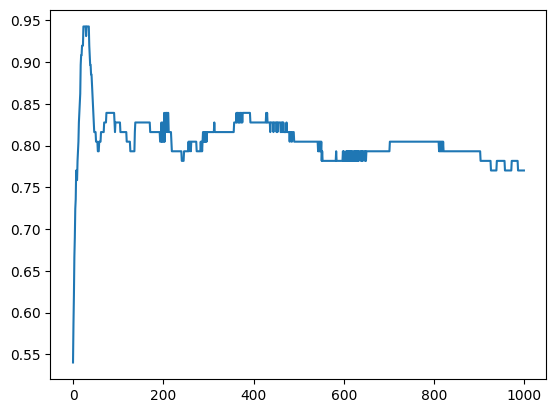

In [ ]:
plt.plot(iters, ACCS)


In [ ]:
_df_sub.to_csv("../input/datasets/fujiden/titanic/answer.csv")

OSError: [Errno 30] Read-only file system: '../input/datasets/fujiden/titanic/answer.csv'

In [ ]:
os.listdir("../input/datasets/fujiden/titanic")

['train.csv', 'test.csv', 'gender_submission.csv']